#  NOVA Quickstart Tutorial

**NOVA -- Next-generation Open Volumetric Archive**

A cloud-native scientific data format for professional astronomy, designed to succeed FITS.

This notebook walks you through the basics of creating, reading, and working with NOVA datasets.

## What you'll learn:
1. Create a NOVA dataset from scratch with synthetic astronomical data
2. Attach structured WCS metadata (JSON-LD)
3. Save and re-open the dataset
4. Perform chunk-based partial reads (cloud-native access)
5. Compare NOVA's structured metadata with FITS keywords

##  Setup

First, install the NOVA library (if not already installed):

In [1]:
%matplotlib inline
# Install nova-py (run once)
# !pip install -e "../nova-py[notebooks]"

import numpy as np
import json
from pathlib import Path
import tempfile
import time

# NOVA imports
from nova.container import NovaDataset, create_dataset
from nova.wcs import NovaWCS, WCSAxis, AffineTransform, CelestialFrame, Projection

print("[ok] NOVA library loaded successfully")
print(f"  NumPy version: {np.__version__}")

[ok] NOVA library loaded successfully
  NumPy version: 2.4.4


## Step 1: Generate Synthetic Astronomical Data

We'll create a realistic simulated sky image with:
- A Gaussian noise background (typical CCD readout noise)
- Several point sources (stars) with Gaussian PSFs
- A 1024x1024 pixel field of view

In [2]:
# Generate synthetic astronomical image
rng = np.random.default_rng(42)

# Background sky with Gaussian noise (typical CCD readout)
sky = rng.normal(loc=1000.0, scale=30.0, size=(1024, 1024)).astype(np.float64)

# Add stars (Gaussian point sources)
n_stars = 50
for _ in range(n_stars):
    cx, cy = rng.integers(0, 1024, size=2)
    flux = rng.uniform(500, 20000)  # Star brightness
    sigma = rng.uniform(1.5, 4.0)   # PSF width
    y, x = np.ogrid[-cx:1024-cx, -cy:1024-cy]
    sky += flux * np.exp(-(x**2 + y**2) / (2 * sigma**2))

print(f"Image shape: {sky.shape}")
print(f"Data type:   {sky.dtype}")
print(f"Value range: [{sky.min():.1f}, {sky.max():.1f}]")
print(f"Raw size:    {sky.nbytes / (1024*1024):.1f} MB")

Image shape: (1024, 1024)
Data type:   float64
Value range: [852.2, 20462.9]
Raw size:    8.0 MB


### Visualize the simulated sky

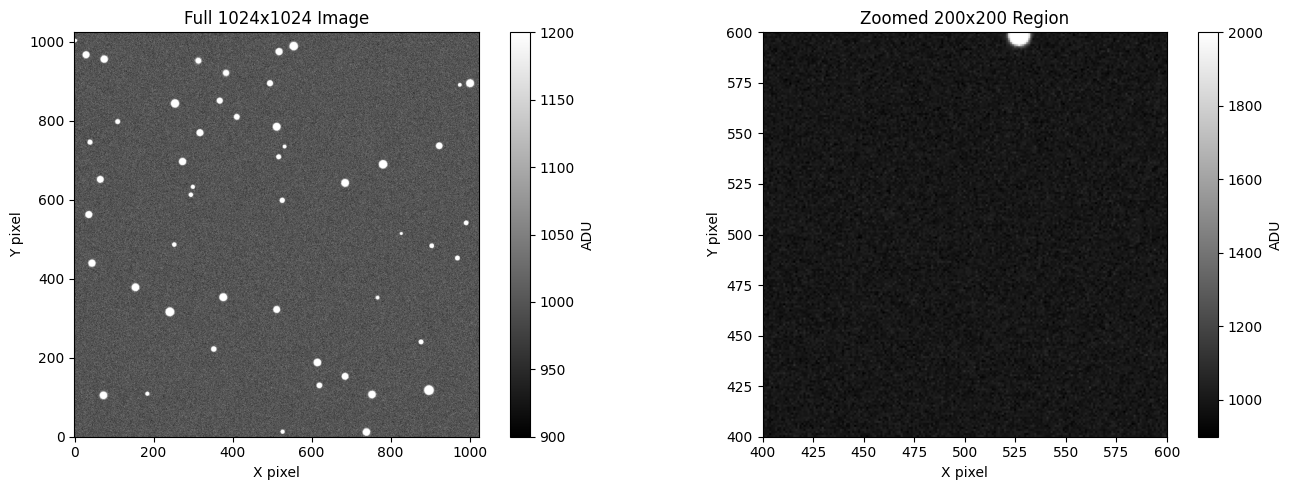

[ok] Synthetic sky image with background + stars generated


In [3]:
from IPython.display import display
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full image
im1 = axes[0].imshow(sky, cmap='gray', vmin=900, vmax=1200, origin='lower')
axes[0].set_title('Full 1024x1024 Image', fontsize=12)
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[0], label='ADU')

# Zoomed region showing stars
im2 = axes[1].imshow(sky[400:600, 400:600], cmap='gray', vmin=900, vmax=2000, origin='lower',
                       extent=[400, 600, 400, 600])
axes[1].set_title('Zoomed 200x200 Region', fontsize=12)
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')
plt.colorbar(im2, ax=axes[1], label='ADU')

plt.tight_layout()
display(fig)
plt.close(fig)
print("[ok] Synthetic sky image with background + stars generated")

## Step 2: Define WCS Metadata

NOVA replaces FITS keyword-based WCS with **structured, typed JSON-LD** metadata:

| FITS (keyword-based) | NOVA (structured JSON-LD) |
|---|---|
| `CTYPE1 = 'RA---TAN'` | `{"@type": "nova:CelestialAxis", "nova:ctype": "RA---TAN", ...}` |
| Flat text, no validation | JSON Schema validated, typed, machine-readable |
| No semantic context | JSON-LD with IVOA UCDs |

In [4]:
# Define structured WCS metadata
wcs = NovaWCS(
    naxes=2,
    axes=[
        WCSAxis(index=0, ctype="RA---TAN", crpix=512.0, crval=150.12, unit="deg"),
        WCSAxis(index=1, ctype="DEC--TAN", crpix=512.0, crval=2.21, unit="deg"),
    ],
    transform=AffineTransform(cd_matrix=[
        [-7.3056e-05, 0.0],   # CD1_1, CD1_2
        [0.0, 7.3056e-05],    # CD2_1, CD2_2
    ]),
    celestial_frame=CelestialFrame(system="ICRS"),
    projection=Projection(code="TAN"),
)

print(f"Projection:  {wcs.projection.name}")
print(f"Frame:       {wcs.celestial_frame.system}")
print(f"Pixel scale: {wcs.transform.pixel_scale:.4f} arcsec/pixel")
print()
print("WCS as JSON-LD:")
print(json.dumps(wcs.to_dict(), indent=2)[:600])
print("...")

Projection:  Gnomonic (Tangent Plane)
Frame:       ICRS
Pixel scale: 0.2630 arcsec/pixel

WCS as JSON-LD:
{
  "@context": "https://nova-astro.org/v0.1/context.jsonld",
  "@type": "nova:WCS",
  "nova:naxes": 2,
  "nova:axes": [
    {
      "@type": "nova:CelestialAxis",
      "nova:index": 0,
      "nova:ctype": "RA---TAN",
      "nova:crpix": 512.0,
      "nova:crval": 150.12,
      "nova:unit": "deg",
      "nova:ucd": "pos.eq.ra"
    },
    {
      "@type": "nova:CelestialAxis",
      "nova:index": 1,
      "nova:ctype": "DEC--TAN",
      "nova:crpix": 512.0,
      "nova:crval": 2.21,
      "nova:unit": "deg",
      "nova:ucd": "pos.eq.dec"
    }
  ],
  "nova:transform": {
    "@type": "nova:Aff
...


## Step 3: Create and Save a NOVA Dataset

A NOVA dataset is a **Zarr v3 store** containing:
- Chunked science data (ZSTD compressed)
- `nova_metadata.json` -- JSON-LD root metadata
- `wcs.json` -- Structured WCS
- `provenance.json` -- W3C PROV-DM lineage
- `nova_index.json` -- Chunk index for cloud access

In [5]:
# Create NOVA dataset in a temporary directory
tmpdir = tempfile.mkdtemp()
store_path = Path(tmpdir) / "my_observation.nova.zarr"

# Create and configure dataset
ds = NovaDataset(store_path, mode="w")
ds.set_science_data(sky, compression_level=3)  # ZSTD level 3
ds.wcs = wcs
ds._metadata.update({
    "nova:observer": "Tutorial User",
    "nova:telescope": "Simulated 2m Telescope",
    "nova:instrument": "SimCam",
    "nova:filter": "r-band",
    "nova:data_level": "L0",
})
ds.save()
ds.close()

# Check file size and compression
total_size = sum(f.stat().st_size for f in store_path.rglob("*") if f.is_file())
print(f"Saved to:      {store_path.name}")
print(f"File size:     {total_size / (1024*1024):.2f} MB")
print(f"Raw size:      {sky.nbytes / (1024*1024):.1f} MB")
print(f"Compression:   {sky.nbytes / total_size:.1f}x")
print()

# List files in the store
print("Store contents:")
for f in sorted(store_path.rglob("*")):
    if f.is_file():
        rel = f.relative_to(store_path)
        print(f"  {rel}  ({f.stat().st_size:,} bytes)")

Saved to:      my_observation.nova.zarr
File size:     7.28 MB
Raw size:      8.0 MB
Compression:   1.1x

Store contents:
  data/science/c/0/0  (7,631,503 bytes)
  data/science/zarr.json  (647 bytes)
  data/zarr.json  (66 bytes)
  nova_metadata.json  (341 bytes)
  wcs.json  (1,071 bytes)
  zarr.json  (66 bytes)


## Step 4: Re-open and Inspect the Dataset

NOVA datasets are self-describing -- all metadata is stored as human-readable JSON files alongside the data.

In [6]:
# Re-open the dataset
ds2 = NovaDataset(store_path, mode="r")

print(f"Data shape:  {ds2.data.shape}")
print(f"Data dtype:  {ds2.data.dtype}")
print(f"WCS type:    {type(ds2.wcs).__name__}")
print(f"Projection:  {ds2.wcs.projection.code}")
print()

# Read JSON-LD metadata
with open(store_path / "nova_metadata.json") as f:
    meta = json.load(f)

print("JSON-LD Metadata:")
print(json.dumps(meta, indent=2))

Data shape:  (1024, 1024)
Data dtype:  float64
WCS type:    NovaWCS
Projection:  TAN

JSON-LD Metadata:
{
  "@context": "https://nova-astro.org/v0.1/context.jsonld",
  "@type": "nova:Observation",
  "nova:version": "0.3.0",
  "nova:created": "2026-04-12T22:01:19.207514+00:00",
  "nova:observer": "Tutorial User",
  "nova:telescope": "Simulated 2m Telescope",
  "nova:instrument": "SimCam",
  "nova:filter": "r-band",
  "nova:data_level": "L0"
}


## Step 5: Cloud-Native Partial Reads

NOVA's **killer feature**: read only the data you need, not the entire file.

This is critical for cloud storage (S3, GCS) where downloading a full 1 GB image to access a 1 MB cutout is wasteful.

In [7]:
# Full read vs partial read comparison
print("Performance Comparison: Full vs Partial Read")
print("=" * 50)

# Full read
t0 = time.perf_counter()
full_data = np.array(ds2.data)
t_full = time.perf_counter() - t0
print(f"Full read:    {sky.shape} = {sky.nbytes/(1024*1024):.1f} MB in {t_full*1000:.2f} ms")

# Small cutout (256x256)
t0 = time.perf_counter()
cutout = np.array(ds2.data[400:656, 400:656])
t_partial = time.perf_counter() - t0
print(f"Partial read: (256, 256) = {cutout.nbytes/1024:.0f} KB in {t_partial*1000:.2f} ms")

print()
print(f"-> Partial read accessed {cutout.nbytes/sky.nbytes*100:.1f}% of the data")
print(f"-> In cloud storage, this means <=2 HTTP Range requests instead of downloading {sky.nbytes/(1024*1024):.0f} MB")

ds2.close()

Performance Comparison: Full vs Partial Read
Full read:    (1024, 1024) = 8.0 MB in 15.75 ms
Partial read: (256, 256) = 512 KB in 10.86 ms

-> Partial read accessed 6.2% of the data
-> In cloud storage, this means <=2 HTTP Range requests instead of downloading 8 MB


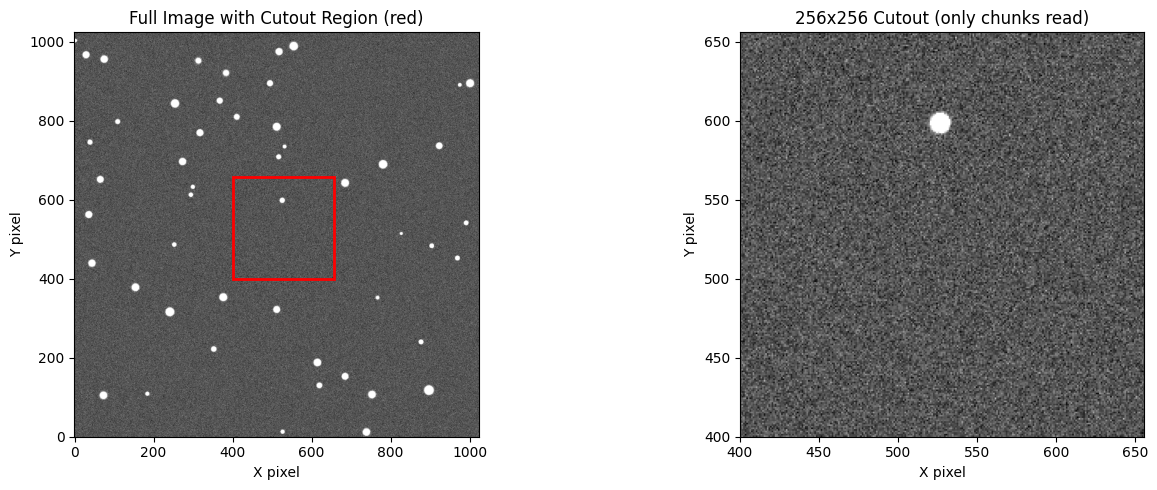

[ok] Only the chunks overlapping the cutout region were read from disk


In [8]:
from IPython.display import display
# Visualize the cutout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(full_data, cmap='gray', vmin=900, vmax=1200, origin='lower')
rect = plt.Rectangle((400, 400), 256, 256, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Full Image with Cutout Region (red)', fontsize=12)
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')

axes[1].imshow(cutout, cmap='gray', vmin=900, vmax=1200, origin='lower',
               extent=[400, 656, 400, 656])
axes[1].set_title('256x256 Cutout (only chunks read)', fontsize=12)
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')

plt.tight_layout()
display(fig)
plt.close(fig)
print("[ok] Only the chunks overlapping the cutout region were read from disk")

##  Summary

| Feature | FITS | NOVA |
|---|---|---|
| **Metadata** | 80-char keyword cards | JSON-LD (typed, validated, semantic) |
| **WCS** | Flat keywords | Structured objects with IVOA UCDs |
| **Compression** | None (base standard) | ZSTD lossless (30-90% savings) |
| **Cloud access** | Download full file | Chunk-based, <=2 HTTP requests |
| **Validation** | None | JSON Schema + JSON-LD |

### Next steps:
- **[Tutorial 02](02_FITS_to_NOVA_Migration.ipynb)**: Migrate existing FITS files to NOVA
- **[Tutorial 03](03_Performance_Benchmarks.ipynb)**: Run performance benchmarks
- Read the **[NOVA Specification](../spec/nova-spec-v0.1.md)** for full details